# London Urban Mobility & Transport Delay Intelligence

**Forecast London Underground disruption risk using real TfL performance data.**

### Operational question
For the next four-week rail period:
- which Tube lines are most likely to experience elevated disruption?
- how many delays longer than 15 minutes should operations teams expect?
- which lines are deteriorating relative to their recent history?
- can a machine-learning model outperform simple historical baselines?

### Real data
The notebook uses the public **London Underground Services Performance Data** published by Transport for London and tidied in the open-source `nacnudus/underground` dataset.

Primary target:
- **Train delays longer than 15 minutes**

### Design
- period-level line performance
- chronological forecasting only
- lag and rolling features
- seasonal-naive baseline
- Extra Trees + XGBoost regression
- MAE, RMSE, WMAPE
- high-disruption risk classification
- feature importance / SHAP
- final ranked London operations watchlist

No passenger-level or personal data is used.

> **Historical-data disclosure:** This is a reproducible **backtest** of TfL Underground reporting-period records from **2003–2018**, not a live service-status feed or a prediction of current 2026 disruptions. The final watchlist is an illustrative next period **after the historical dataset ends**.


In [1]:
# Colab / GitHub Actions safe setup
import sys, subprocess, importlib.util

required = {
    "xgboost": "xgboost",
    "shap": "shap"
}
for module, package in required.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Environment ready.")

Environment ready.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported.")

Libraries imported.


## 1. Load real TfL Underground performance data

The raw data originate from TfL's Underground performance spreadsheets. This notebook reads the tidy CSV mirror maintained in the `nacnudus/underground` open-source package so the analysis is reproducible.

In [3]:
UNDERGROUND_URL = "https://raw.githubusercontent.com/nacnudus/underground/master/inst/extdata/underground.csv.gz"
PERIODS_URL = "https://raw.githubusercontent.com/nacnudus/underground/master/inst/extdata/rail_periods.csv.gz"

underground = pd.read_csv(UNDERGROUND_URL, compression="gzip")
periods = pd.read_csv(PERIODS_URL, compression="gzip")

# Normalise historical naming conventions used by the source package.
if "fourweek" in underground.columns and "period" not in underground.columns:
    underground = underground.rename(columns={"fourweek":"period"})

periods = periods.rename(columns={
    "start_date":"start",
    "end_date":"end"
})
periods["start"] = pd.to_datetime(periods["start"], errors="coerce")
if "end" in periods.columns:
    periods["end"] = pd.to_datetime(periods["end"], errors="coerce")

print(f"Underground performance rows: {len(underground):,}")
print(f"Metrics available: {underground['metric'].nunique():,}")
print(f"Lines represented: {underground['line'].nunique(dropna=True):,}")
print("Underground columns:", underground.columns.tolist())
print("Period lookup columns:", periods.columns.tolist())

display(underground.head())
display(periods.head())

Underground performance rows: 109,647
Metrics available: 52
Lines represented: 11
Underground columns: ['metric', 'year', 'quarter', 'period', 'line', 'category', 'asset', 'company', 'value']
Period lookup columns: ['year', 'period', 'start', 'end', 'days']


,metric,year,quarter,period,line,category,asset,company,value
0,% of Schedule Operated,2003/04,NaN,1.000,All Lines,NaN,NaN,NaN,0.917
1,% of Schedule Operated,2003/04,NaN,1.000,Bakerloo,NaN,NaN,NaN,0.924
2,% of Schedule Operated,2003/04,NaN,1.000,Central,NaN,NaN,NaN,0.703
3,% of Schedule Operated,2003/04,NaN,1.000,Circle + H&C,NaN,NaN,NaN,0.862
4,% of Schedule Operated,2003/04,NaN,1.000,District,NaN,NaN,NaN,0.972


,year,period,start,end,days
0,1995/96,1,1995-04-01,1995-04-29,28
1,1995/96,2,1995-04-30,1995-05-27,27
2,1995/96,3,1995-05-28,1995-06-24,27
3,1995/96,4,1995-06-25,1995-07-22,27
4,1995/96,5,1995-07-23,1995-08-19,27


## 2. Isolate the operational delay target

The target is the number of **train delays longer than 15 minutes** per line and four-week rail period. Network totals are removed so every row represents one operating line.

In [4]:
TARGET_METRIC = "Train delays longer than 15 minutes"

delay = underground.loc[
    (underground["metric"] == TARGET_METRIC)
    & underground["line"].notna()
    & underground["period"].notna()
].copy()

delay = delay.loc[
    ~delay["line"].astype(str).str.contains("All Lines", case=False, na=False)
].copy()

delay["period"] = pd.to_numeric(delay["period"], errors="coerce")
delay["value"] = pd.to_numeric(delay["value"], errors="coerce")
delay = delay.dropna(subset=["period","value"])
delay["period"] = delay["period"].astype(int)

# Resolve rail periods to real dates.
period_lookup = periods[["year","period","start"]].drop_duplicates()
delay = delay.merge(period_lookup, on=["year","period"], how="left")
delay = delay.dropna(subset=["start"]).sort_values(["line","start"])

delay = delay.rename(columns={"value":"delay_count"})

print(f"Line-period observations: {len(delay):,}")
print(f"Date range: {delay['start'].min().date()} -> {delay['start'].max().date()}")
print(f"Lines: {sorted(delay['line'].unique().tolist())}")
display(delay.head(12))

Line-period observations: 2,000
Date range: 2003-04-01 -> 2018-07-22
Lines: ['Bakerloo', 'Central', 'Circle + H&C', 'District', 'Jubilee', 'Metropolitan', 'Northern', 'Piccadilly', 'Victoria', 'Waterloo & City']


,metric,year,quarter,period,line,category,asset,company,delay_count,start
0,Train delays longer than 15 minutes,2003/04,NaN,1,Bakerloo,NaN,NaN,NaN,21.000,2003-04-01
10,Train delays longer than 15 minutes,2003/04,NaN,2,Bakerloo,NaN,NaN,NaN,27.000,2003-04-27
20,Train delays longer than 15 minutes,2003/04,NaN,3,Bakerloo,NaN,NaN,NaN,15.000,2003-05-25
30,Train delays longer than 15 minutes,2003/04,NaN,4,Bakerloo,NaN,NaN,NaN,14.000,2003-06-22
40,Train delays longer than 15 minutes,2003/04,NaN,5,Bakerloo,NaN,NaN,NaN,24.000,2003-07-20
50,Train delays longer than 15 minutes,2003/04,NaN,6,Bakerloo,NaN,NaN,NaN,13.000,2003-08-17
60,Train delays longer than 15 minutes,2003/04,NaN,7,Bakerloo,NaN,NaN,NaN,16.000,2003-09-14
70,Train delays longer than 15 minutes,2003/04,NaN,8,Bakerloo,NaN,NaN,NaN,31.000,2003-10-12
80,Train delays longer than 15 minutes,2003/04,NaN,9,Bakerloo,NaN,NaN,NaN,25.000,2003-11-09
90,Train delays longer than 15 minutes,2003/04,NaN,10,Bakerloo,NaN,NaN,NaN,30.000,2003-12-07


## 3. Exploratory disruption intelligence

,periods,avg_delays,median_delays,max_delays,total_delays
line,,,,,
District,200,26.835,24.500,70.000,"5,367.000"
Metropolitan,200,24.315,23.000,56.000,"4,863.000"
Piccadilly,200,21.470,19.000,76.000,"4,294.000"
Central,200,18.725,17.000,88.000,"3,745.000"
Northern,200,14.990,13.000,42.000,"2,998.000"
Bakerloo,200,13.845,12.000,50.000,"2,769.000"
Jubilee,200,12.195,12.000,36.000,"2,439.000"
Circle + H&C,200,10.985,10.000,34.000,"2,197.000"
Victoria,200,8.030,7.000,25.000,"1,606.000"


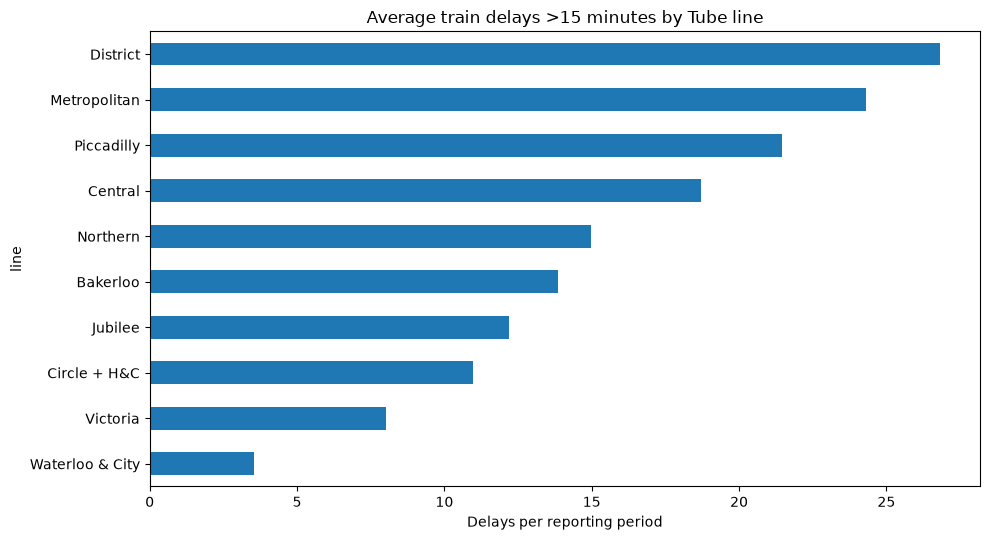

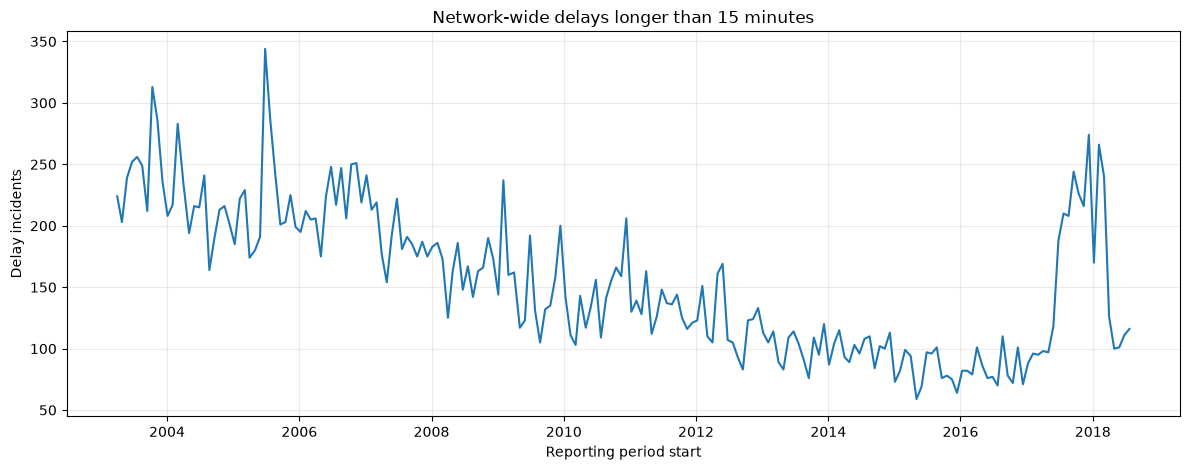

In [5]:
line_summary = (
    delay.groupby("line")
    .agg(
        periods=("delay_count","size"),
        avg_delays=("delay_count","mean"),
        median_delays=("delay_count","median"),
        max_delays=("delay_count","max"),
        total_delays=("delay_count","sum")
    )
    .sort_values("avg_delays", ascending=False)
)

display(line_summary)

fig, ax = plt.subplots(figsize=(10, 5.5))
line_summary["avg_delays"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Average train delays >15 minutes by Tube line")
ax.set_xlabel("Delays per reporting period")
plt.tight_layout()
plt.show()

network_period = delay.groupby("start")["delay_count"].sum()
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(network_period.index, network_period.values)
ax.set_title("Network-wide delays longer than 15 minutes")
ax.set_ylabel("Delay incidents")
ax.set_xlabel("Reporting period start")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Leakage-safe time-series features

Every historical disruption feature is shifted, so the model can only see information available **before** the period being forecast.

In [6]:
delay = delay.sort_values(["line","start"]).copy()
g = delay.groupby("line", group_keys=False)

for lag in [1,2,3,6,13]:
    delay[f"lag_{lag}"] = g["delay_count"].shift(lag)

for window in [3,6,13]:
    delay[f"rolling_mean_{window}"] = g["delay_count"].transform(
        lambda s: s.shift(1).rolling(window).mean()
    )
    delay[f"rolling_std_{window}"] = g["delay_count"].transform(
        lambda s: s.shift(1).rolling(window).std()
    )

delay["trend_3_vs_13"] = (
    delay["rolling_mean_3"] - delay["rolling_mean_13"]
)
delay["period_sin"] = np.sin(2*np.pi*delay["period"]/13)
delay["period_cos"] = np.cos(2*np.pi*delay["period"]/13)

# Financial year numeric index.
delay["year_start"] = pd.to_numeric(
    delay["year"].astype(str).str.extract(r"(\d{4})")[0],
    errors="coerce"
)

model_df = delay.dropna(subset=[
    "lag_1","lag_2","lag_3","lag_6","lag_13",
    "rolling_mean_3","rolling_mean_6","rolling_mean_13",
    "rolling_std_3","rolling_std_6","rolling_std_13",
    "trend_3_vs_13","year_start"
]).copy()

print(f"Model-ready line-period rows: {len(model_df):,}")
print(f"Model-ready date range: {model_df['start'].min().date()} -> {model_df['start'].max().date()}")

Model-ready line-period rows: 1,870
Model-ready date range: 2004-04-01 -> 2018-07-22


## 5. Strict chronological train / validation / test split

The final 13 reporting periods are held out as the untouched test horizon. The preceding 13 periods are validation data.

In [7]:
unique_dates = np.array(sorted(model_df["start"].unique()))
if len(unique_dates) < 40:
    raise ValueError("Not enough reporting periods for chronological evaluation.")

test_dates = unique_dates[-13:]
val_dates = unique_dates[-26:-13]

train_df = model_df.loc[~model_df["start"].isin(np.concatenate([val_dates,test_dates]))].copy()
val_df = model_df.loc[model_df["start"].isin(val_dates)].copy()
test_df = model_df.loc[model_df["start"].isin(test_dates)].copy()

feature_cols = [
    "lag_1","lag_2","lag_3","lag_6","lag_13",
    "rolling_mean_3","rolling_mean_6","rolling_mean_13",
    "rolling_std_3","rolling_std_6","rolling_std_13",
    "trend_3_vs_13","period","period_sin","period_cos","year_start"
]

def make_matrix(frame):
    base = frame[feature_cols + ["line"]].copy()
    return pd.get_dummies(base, columns=["line"], prefix="line", dtype=float)

all_cols = make_matrix(model_df).columns.tolist()

def matrix_for(frame):
    return make_matrix(frame).reindex(columns=all_cols, fill_value=0.0)

X_train, y_train = matrix_for(train_df), train_df["delay_count"].astype(float)
X_val, y_val = matrix_for(val_df), val_df["delay_count"].astype(float)
X_test, y_test = matrix_for(test_df), test_df["delay_count"].astype(float)

split_summary = pd.DataFrame({
    "rows":[len(train_df),len(val_df),len(test_df)],
    "periods":[train_df["start"].nunique(),val_df["start"].nunique(),test_df["start"].nunique()],
    "start":[train_df["start"].min(),val_df["start"].min(),test_df["start"].min()],
    "end":[train_df["start"].max(),val_df["start"].max(),test_df["start"].max()]
}, index=["train","validation","test"])

display(split_summary)
print(f"Feature count after line encoding: {len(all_cols)}")

,rows,periods,start,end
train,1610,161,2004-04-01,2016-07-24
validation,130,13,2016-08-21,2017-07-23
test,130,13,2017-08-20,2018-07-22


Feature count after line encoding: 26


## 6. Forecast model comparison and per-line champion selection

Tube lines have different operating patterns. Validation therefore selects the best forecaster **independently for each line** from:
- previous reporting period;
- same reporting period last year;
- Extra Trees;
- XGBoost.

The mapping is frozen before the untouched final-year test.

In [8]:
extra = ExtraTreesRegressor(
    n_estimators=400,
    min_samples_leaf=2,
    max_features=0.85,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
extra.fit(X_train, y_train)

xgb = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=2,
    reg_lambda=2.0,
    reg_alpha=0.05,
    objective="reg:squarederror",
    eval_metric="mae",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

val_pred_extra = np.clip(extra.predict(X_val), 0, None)
val_pred_xgb = np.clip(xgb.predict(X_val), 0, None)
val_pred_lag1 = np.clip(val_df["lag_1"].to_numpy(), 0, None)
val_pred_seasonal = np.clip(val_df["lag_13"].to_numpy(), 0, None)

print("Models trained.")

Models trained.


,MAE,RMSE,WMAPE,bias
model,,,,
Line champion ensemble,3.82,5.84,34.97%,-15.46%
Extra Trees,4.07,6.31,37.25%,-20.97%
XGBoost,4.20,6.41,38.39%,-23.07%
Previous period,4.37,5.80,39.94%,-9.85%
Same period last year,4.90,7.81,44.80%,-26.37%


Frozen validation-selected line champions:


,champion
line,
Bakerloo,Extra Trees
Central,Extra Trees
Circle + H&C,XGBoost
District,Previous period
Jubilee,Extra Trees
Metropolitan,Extra Trees
Northern,Extra Trees
Piccadilly,Previous period
Victoria,XGBoost



Champion counts:


,line_count
Extra Trees,5
XGBoost,3
Previous period,2


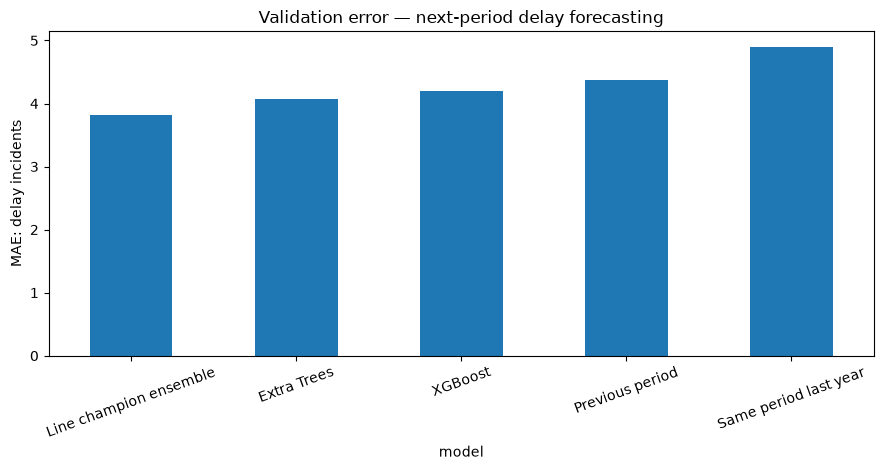

In [9]:
def regression_metrics(name, y_true, pred):
    y = np.asarray(y_true, dtype=float)
    p = np.asarray(pred, dtype=float)
    return {
        "model":name,
        "MAE":mean_absolute_error(y,p),
        "RMSE":mean_squared_error(y,p)**0.5,
        "WMAPE":np.abs(y-p).sum()/max(np.abs(y).sum(),1e-12),
        "bias":(p-y).sum()/max(y.sum(),1e-12)
    }

val_compare = val_df[["line","delay_count"]].copy()
val_compare["Previous period"] = val_pred_lag1
val_compare["Same period last year"] = val_pred_seasonal
val_compare["Extra Trees"] = val_pred_extra
val_compare["XGBoost"] = val_pred_xgb

candidate_models = [
    "Previous period",
    "Same period last year",
    "Extra Trees",
    "XGBoost"
]

line_validation_mae = pd.DataFrame({
    model: val_compare.groupby("line").apply(
        lambda g, m=model: np.mean(np.abs(g["delay_count"] - g[m])),
        include_groups=False
    )
    for model in candidate_models
})

champion_by_line = line_validation_mae.idxmin(axis=1)

def apply_line_champions(frame, pred_lag1, pred_seasonal, pred_extra, pred_xgb):
    arrays = {
        "Previous period":np.asarray(pred_lag1),
        "Same period last year":np.asarray(pred_seasonal),
        "Extra Trees":np.asarray(pred_extra),
        "XGBoost":np.asarray(pred_xgb)
    }
    out = np.zeros(len(frame),dtype=float)
    for i,line in enumerate(frame["line"].values):
        out[i] = arrays[champion_by_line.loc[line]][i]
    return out

val_pred_champion = apply_line_champions(
    val_df,val_pred_lag1,val_pred_seasonal,val_pred_extra,val_pred_xgb
)

val_results = pd.DataFrame([
    regression_metrics("Previous period", y_val, val_pred_lag1),
    regression_metrics("Same period last year", y_val, val_pred_seasonal),
    regression_metrics("Extra Trees", y_val, val_pred_extra),
    regression_metrics("XGBoost", y_val, val_pred_xgb),
    regression_metrics("Line champion ensemble", y_val, val_pred_champion)
]).set_index("model").sort_values("MAE")

display(val_results.style.format({
    "MAE":"{:.2f}","RMSE":"{:.2f}",
    "WMAPE":"{:.2%}","bias":"{:+.2%}"
}))

print("Frozen validation-selected line champions:")
display(champion_by_line.rename("champion").to_frame())
print("\nChampion counts:")
display(champion_by_line.value_counts().rename("line_count").to_frame())

best_name = "Line champion ensemble"

fig, ax = plt.subplots(figsize=(9,4.8))
val_results.sort_values("MAE")["MAE"].plot(kind="bar", ax=ax)
ax.set_title("Validation error — next-period delay forecasting")
ax.set_ylabel("MAE: delay incidents")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 7. Untouched test evaluation

In [10]:
test_pred_extra = np.clip(extra.predict(X_test), 0, None)
test_pred_xgb = np.clip(xgb.predict(X_test), 0, None)
test_pred_lag1 = np.clip(test_df["lag_1"].to_numpy(), 0, None)
test_pred_seasonal = np.clip(test_df["lag_13"].to_numpy(), 0, None)

test_pred_champion = apply_line_champions(
    test_df,test_pred_lag1,test_pred_seasonal,test_pred_extra,test_pred_xgb
)
test_pred_best = test_pred_champion
best_name = "Line champion ensemble"

test_results = pd.DataFrame([
    regression_metrics("Previous period", y_test, test_pred_lag1),
    regression_metrics("Same period last year", y_test, test_pred_seasonal),
    regression_metrics("Extra Trees", y_test, test_pred_extra),
    regression_metrics("XGBoost", y_test, test_pred_xgb),
    regression_metrics("Line champion ensemble", y_test, test_pred_champion)
]).set_index("model").sort_values("MAE")

display(test_results.style.format({
    "MAE":"{:.2f}","RMSE":"{:.2f}",
    "WMAPE":"{:.2%}","bias":"{:+.2%}"
}))

chosen_test = test_results.loc["Line champion ensemble"]
baseline_test = test_results.loc["Previous period"]

print(f"""
FINAL DELAY-FORECAST RESULT
---------------------------
Deployment strategy: Line champion ensemble
Test MAE: {chosen_test['MAE']:.2f} delay incidents
Test RMSE: {chosen_test['RMSE']:.2f}
Test WMAPE: {chosen_test['WMAPE']:.2%}
Previous-period baseline MAE: {baseline_test['MAE']:.2f}
MAE change vs previous-period baseline: {(chosen_test['MAE']/baseline_test['MAE']-1):+.2%}
""")

,MAE,RMSE,WMAPE,bias
model,,,,
Previous period,7.42,11.77,40.20%,+3.92%
Line champion ensemble,7.48,11.46,40.56%,-4.65%
XGBoost,7.70,11.54,41.74%,-7.70%
Extra Trees,7.83,11.76,42.46%,-8.47%
Same period last year,11.38,16.70,61.72%,-40.70%



FINAL DELAY-FORECAST RESULT
---------------------------
Deployment strategy: Line champion ensemble
Test MAE: 7.48 delay incidents
Test RMSE: 11.46
Test WMAPE: 40.56%
Previous-period baseline MAE: 7.42
MAE change vs previous-period baseline: +0.90%



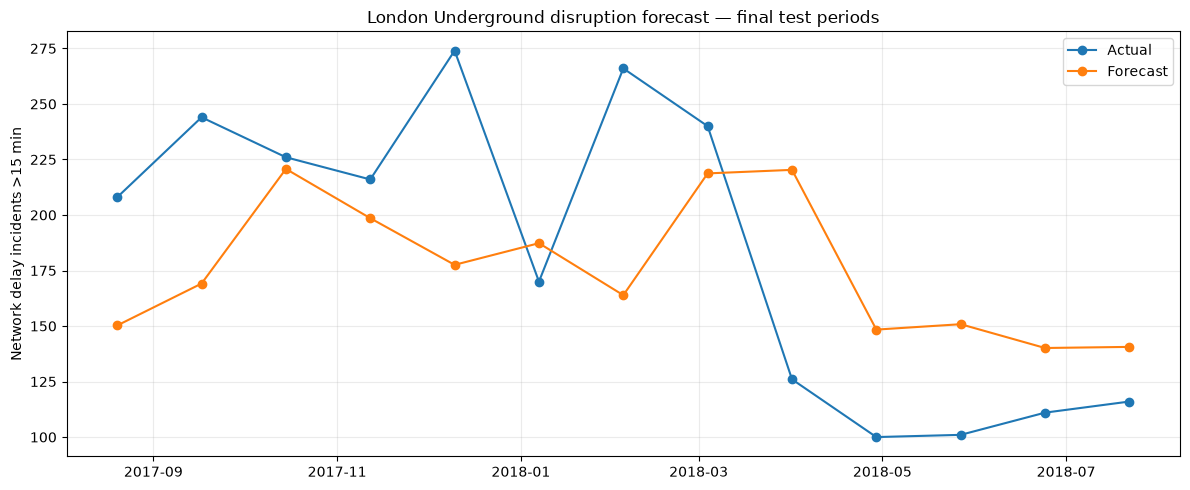

,actual_delays,forecast_delays,MAE
line,,,
Central,431.000,370.097,16.001
Piccadilly,424.000,441.000,13.462
District,428.000,431.000,11.923
Metropolitan,291.000,267.821,8.793
Northern,226.000,232.958,6.136
Bakerloo,234.000,187.032,4.981
Circle + H&C,117.000,113.580,4.099
Victoria,94.000,85.957,4.099
Jubilee,125.000,125.695,3.676


In [11]:
test_view = test_df[["start","line","delay_count"]].copy()
test_view["prediction"] = test_pred_best

actual_net = test_view.groupby("start")["delay_count"].sum()
pred_net = test_view.groupby("start")["prediction"].sum()

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(actual_net.index, actual_net.values, marker="o", label="Actual")
ax.plot(pred_net.index, pred_net.values, marker="o", label="Forecast")
ax.set_title("London Underground disruption forecast — final test periods")
ax.set_ylabel("Network delay incidents >15 min")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

line_errors = (
    test_view.assign(abs_error=lambda d: (d["delay_count"]-d["prediction"]).abs())
    .groupby("line")
    .agg(actual_delays=("delay_count","sum"),
         forecast_delays=("prediction","sum"),
         MAE=("abs_error","mean"))
    .sort_values("MAE", ascending=False)
)
display(line_errors)

## 8. High-disruption risk classification

A separate operational view converts the numeric forecast into a risk flag. The high-disruption threshold is defined **from the training set only** as the 75th percentile of delay counts.

,threshold_delay_count,precision,recall,f1
0,20.0,72.73%,69.57%,0.711


                 precision    recall  f1-score   support

   Normal/Lower       0.84      0.86      0.85        84
High disruption       0.73      0.70      0.71        46

       accuracy                           0.80       130
      macro avg       0.78      0.78      0.78       130
   weighted avg       0.80      0.80      0.80       130



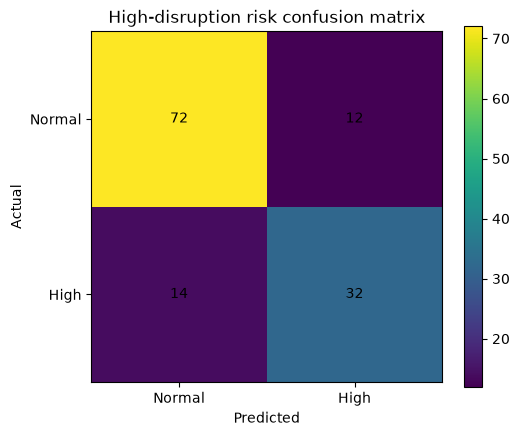

In [12]:
high_threshold = float(train_df["delay_count"].quantile(0.75))

test_actual_high = (y_test.to_numpy() >= high_threshold).astype(int)
test_pred_high = (test_pred_best >= high_threshold).astype(int)

risk_metrics = {
    "threshold_delay_count":high_threshold,
    "precision":precision_score(test_actual_high,test_pred_high,zero_division=0),
    "recall":recall_score(test_actual_high,test_pred_high,zero_division=0),
    "f1":f1_score(test_actual_high,test_pred_high,zero_division=0)
}
display(pd.DataFrame([risk_metrics]).style.format({
    "threshold_delay_count":"{:.1f}",
    "precision":"{:.2%}",
    "recall":"{:.2%}",
    "f1":"{:.3f}"
}))

print(classification_report(
    test_actual_high,test_pred_high,
    target_names=["Normal/Lower","High disruption"],
    zero_division=0
))

cm = confusion_matrix(test_actual_high,test_pred_high)
fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(cm)
ax.set_title("High-disruption risk confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0,1],["Normal","High"])
ax.set_yticks([0,1],["Normal","High"])
for i in range(2):
    for j in range(2):
        ax.text(j,i,str(cm[i,j]),ha="center",va="center")
plt.colorbar(im,ax=ax)
plt.tight_layout()
plt.show()

## 9. Explainability — what drives the ML component?

The deployed strategy is a per-line champion ensemble. XGBoost remains one candidate component, so feature importance and SHAP are used to explain the machine-learning disruption signal.

,importance
rolling_mean_13,0.383
rolling_mean_6,0.236
Tube line identity,0.148
lag_1,0.024
rolling_mean_3,0.023
period_sin,0.021
period,0.019
year_start,0.016
period_cos,0.016
rolling_std_13,0.016


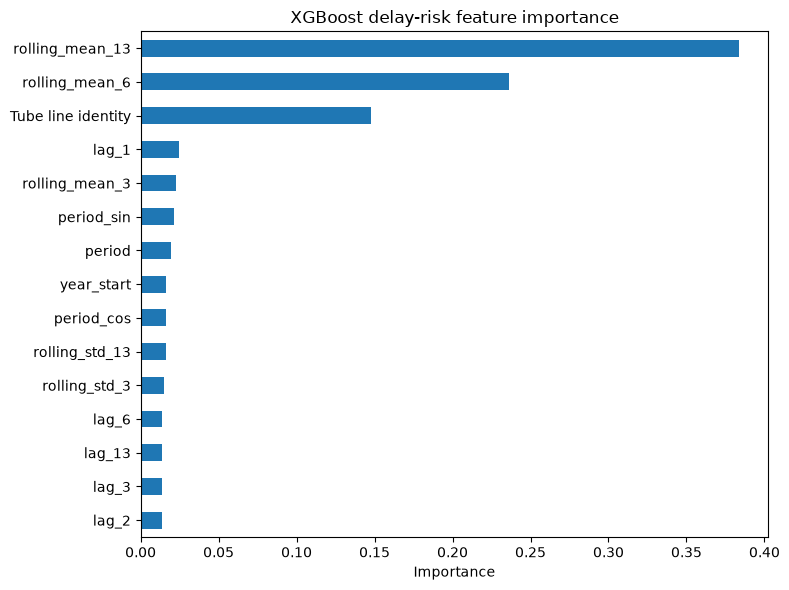

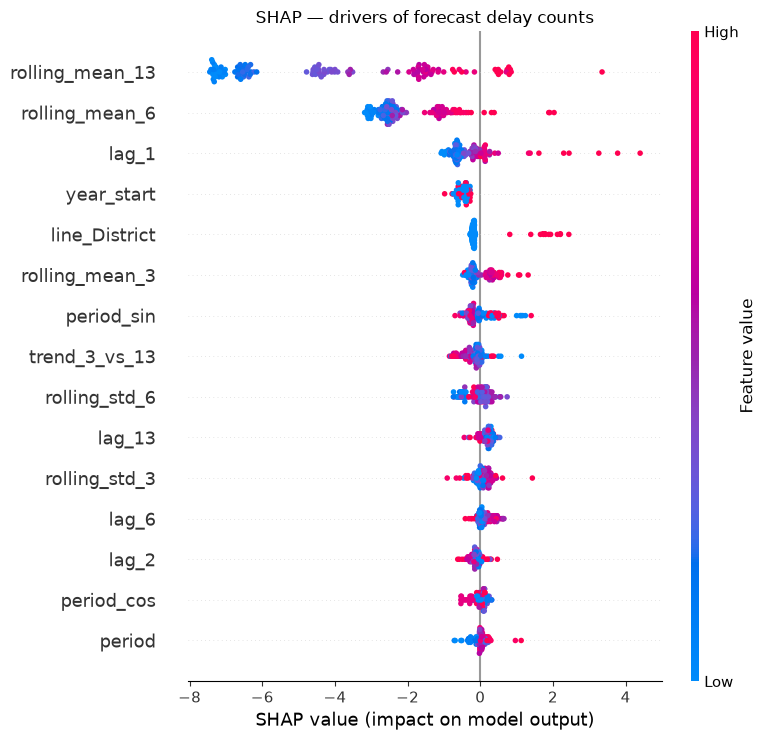

In [13]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Group line dummy variables into one readable family.
readable = {}
for feature, value in xgb_importance.items():
    key = "Tube line identity" if feature.startswith("line_") else feature
    readable[key] = readable.get(key,0.0) + float(value)

readable_importance = pd.Series(readable).sort_values(ascending=False).head(15)
display(readable_importance.to_frame("importance"))

fig, ax = plt.subplots(figsize=(8,6))
readable_importance.sort_values().plot(kind="barh", ax=ax)
ax.set_title("XGBoost delay-risk feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

import shap
sample = X_val.sample(min(500,len(X_val)),random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values,sample,max_display=15,show=False)
plt.title("SHAP — drivers of forecast delay counts")
plt.tight_layout()
plt.show()

## 10. Next-period London operations watchlist

For each Tube line, the latest available state is transformed into one synthetic “next-period” feature row using only historical observations. This creates an operational ranking rather than stopping at model metrics.

**2018 backtest only:** The watchlist projects the next reporting period after the last historical observation. It should not be used to assess today's Underground operations.


In [14]:
latest_rows = []

for line, grp in delay.sort_values("start").groupby("line"):
    grp = grp.sort_values("start").copy()
    if len(grp) < 13:
        continue

    recent = grp["delay_count"].astype(float)
    latest = grp.iloc[-1]

    next_period = int(latest["period"]) + 1
    next_year_start = int(str(latest["year"]).split("/")[0])

    if next_period > 13:
        next_period = 1
        next_year_start += 1

    latest_rows.append({
        "line":line,
        "lag_1":recent.iloc[-1],
        "lag_2":recent.iloc[-2],
        "lag_3":recent.iloc[-3],
        "lag_6":recent.iloc[-6],
        "lag_13":recent.iloc[-13],
        "rolling_mean_3":recent.iloc[-3:].mean(),
        "rolling_mean_6":recent.iloc[-6:].mean(),
        "rolling_mean_13":recent.iloc[-13:].mean(),
        "rolling_std_3":recent.iloc[-3:].std(),
        "rolling_std_6":recent.iloc[-6:].std(),
        "rolling_std_13":recent.iloc[-13:].std(),
        "trend_3_vs_13":recent.iloc[-3:].mean()-recent.iloc[-13:].mean(),
        "period":next_period,
        "period_sin":np.sin(2*np.pi*next_period/13),
        "period_cos":np.cos(2*np.pi*next_period/13),
        "year_start":next_year_start
    })

next_period_df = pd.DataFrame(latest_rows)
X_next = make_matrix(next_period_df).reindex(columns=all_cols,fill_value=0.0)

next_extra = np.clip(extra.predict(X_next),0,None)
next_xgb = np.clip(xgb.predict(X_next),0,None)
next_lag1 = next_period_df["lag_1"].to_numpy()
next_seasonal = next_period_df["lag_13"].to_numpy()

next_pred = apply_line_champions(
    next_period_df,next_lag1,next_seasonal,next_extra,next_xgb
)

watchlist = next_period_df[[
    "line","lag_1","rolling_mean_3","rolling_mean_13","trend_3_vs_13"
]].copy()
watchlist["champion_model"] = watchlist["line"].map(champion_by_line)
watchlist["predicted_delays_gt15min"] = next_pred
watchlist["high_disruption_risk"] = (
    watchlist["predicted_delays_gt15min"] >= high_threshold
)
watchlist["risk_score_vs_threshold"] = (
    watchlist["predicted_delays_gt15min"] / max(high_threshold,1e-9)
)
watchlist = watchlist.sort_values(
    ["high_disruption_risk","predicted_delays_gt15min"],
    ascending=[False,False]
)

print("Next-period Tube operations watchlist:")
display(watchlist)

watchlist.to_csv("london_tube_next_period_risk_watchlist.csv",index=False)
test_results.to_csv("london_tube_delay_forecast_metrics.csv")
line_errors.to_csv("london_tube_line_test_errors.csv")
print("Operational artefacts exported.")

Next-period Tube operations watchlist:


,line,lag_1,rolling_mean_3,rolling_mean_13,trend_3_vs_13,champion_model,predicted_delays_gt15min,high_disruption_risk,risk_score_vs_threshold
1,Central,9.000,14.000,33.154,-19.154,Extra Trees,24.210,True,1.211
3,District,23.000,20.000,32.923,-12.923,Previous period,23.000,True,1.150
5,Metropolitan,17.000,15.000,22.385,-7.385,Extra Trees,18.265,False,0.913
7,Piccadilly,17.000,17.000,32.615,-15.615,Previous period,17.000,False,0.850
6,Northern,16.000,10.667,17.385,-6.718,Extra Trees,15.287,False,0.764
0,Bakerloo,16.000,15.333,18.000,-2.667,Extra Trees,14.406,False,0.720
4,Jubilee,6.000,5.000,9.615,-4.615,Extra Trees,8.706,False,0.435
2,Circle + H&C,5.000,8.667,9.000,-0.333,XGBoost,7.734,False,0.387
8,Victoria,4.000,2.667,7.231,-4.564,XGBoost,7.468,False,0.373
9,Waterloo & City,3.000,1.000,2.154,-1.154,XGBoost,2.629,False,0.131


Operational artefacts exported.


## 11. Executive summary

In [15]:
highest_risk = watchlist.iloc[0]

print(f"""
LONDON URBAN MOBILITY & DELAY INTELLIGENCE
------------------------------------------
Source: TfL London Underground performance data
Target: train delays longer than 15 minutes
Forecast unit: Tube line x four-week reporting period
Model-ready observations: {len(model_df):,}
Lines modelled: {model_df['line'].nunique()}

Deployment strategy: Line champion ensemble
Test MAE: {chosen_test['MAE']:.2f}
Test WMAPE: {chosen_test['WMAPE']:.2%}
MAE change vs previous-period baseline: {(chosen_test['MAE']/baseline_test['MAE']-1):+.2%}
High-disruption precision: {risk_metrics['precision']:.2%}
High-disruption recall: {risk_metrics['recall']:.2%}

Highest next-period risk line: {highest_risk['line']}
Champion model: {highest_risk['champion_model']}
Forecast delays >15 min: {highest_risk['predicted_delays_gt15min']:.1f}
Training-defined high-risk threshold: {high_threshold:.1f}

The system lets each Tube line use the forecasting method selected
from validation history, while the final-year test remains untouched.
""")


LONDON URBAN MOBILITY & DELAY INTELLIGENCE
------------------------------------------
Source: TfL London Underground performance data
Target: train delays longer than 15 minutes
Forecast unit: Tube line x four-week reporting period
Model-ready observations: 1,870
Lines modelled: 10

Deployment strategy: Line champion ensemble
Test MAE: 7.48
Test WMAPE: 40.56%
MAE change vs previous-period baseline: +0.90%
High-disruption precision: 72.73%
High-disruption recall: 69.57%

Highest next-period risk line: Central
Champion model: Extra Trees
Forecast delays >15 min: 24.2
Training-defined high-risk threshold: 20.0

The system lets each Tube line use the forecasting method selected
from validation history, while the final-year test remains untouched.



### Production roadmap
- ingest the latest TfL service-status history and iBus reliability feeds;
- combine planned engineering works, weather and event calendars;
- add station-level crowding / entry-exit demand;
- model disruption duration and passenger-hours impact, not only incident counts;
- hierarchical forecasting from line to network;
- probabilistic prediction intervals;
- live API scoring and operations dashboard;
- drift monitoring and automatic model/champion re-selection;
- causal post-incident analysis for root-cause categories.

### Interview defence
**“I used real TfL performance data with a strict chronological split and only lagged signals available before each reporting period. Because Tube lines behave differently, I selected a champion forecaster per line using validation data only, froze that mapping before the final-year test, translated numeric forecasts into high-disruption risk, and produced a ranked next-period operations watchlist.”**

### Backtest interpretation and limitations
The selected per-line champion system did **not** outperform a previous-period persistence baseline in the untouched test year: test MAE was **7.48 incidents per line-period**, **0.90% higher** than the baseline. That honest null/negative result matters: complexity should not be deployed without added value. Its disruption-risk triage view achieved approximately **72.73% precision** and **69.57% recall**, and may still be informative as a demonstration of turning line-level performance into a review queue. This simulation lacks passenger exposure, route-level geography, detailed incident causes, and current TfL feeds.
